#Healthcare Diabetes Analysis
##Exploratory DataAnalysis using Python
###DataSet:Pima Indians Diabetes Dataset
###Tools: Python(Pandas,matplotlib,Seaborn)
###By:Bhavitha S A

In [1]:
from google.colab import files
uploaded = files.upload()


Saving diabetes.csv to diabetes.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully")

All libraries imported successfully


In [3]:
#loading data
df=pd.read_csv("diabetes.csv")
#total rows and columns in data
print("Total rows and columns in data")
df.shape
#First look at data
print("First 5 rows of data")
df.head()



Total rows and columns in data
First 5 rows of data


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


##Exploratory Analysis
Understanding the basic statistics and structure of dataset

In [4]:
#knowing datatypes of columns
print("Datatypes ogf columns",df.dtypes)
print("\n")

#knowing structure of columns
print("Structure of columns")
df.describe()

Datatypes ogf columns Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


Structure of columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## column names and datatypes

In [5]:
print("columnn names and datatypes",df.dtypes)

columnn names and datatypes Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


knowing hidden zero counts

In [6]:
zero_counts=(df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']]==0).sum()
print("Hidden zero counts")
print(zero_counts)
print("zero count percentage:")
print(round(zero_counts/len(df)*100,2))

Hidden zero counts
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64
zero count percentage:
Glucose          0.0
BloodPressure    0.0
SkinThickness    0.0
Insulin          0.0
BMI              0.0
dtype: float64


## finding total count of missing values

In [7]:
print("missingvalue of each column")
print(df.isnull().sum())
# total missing value of all col
print("total missing value",df.isnull().sum().sum())

missingvalue of each column
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
total missing value 0


##Diabetic distribution

In [8]:
print("Diabetic distribution")
print(df['Outcome'].value_counts())
#percentage of diabetic vs nondiabetic
print("percentage of diabetic vs nondiabetic")
print(df['Outcome'].value_counts(normalize=True)*100)

Diabetic distribution
Outcome
0    500
1    268
Name: count, dtype: int64
percentage of diabetic vs nondiabetic
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


# Chart 1 - Diabetes Distribution

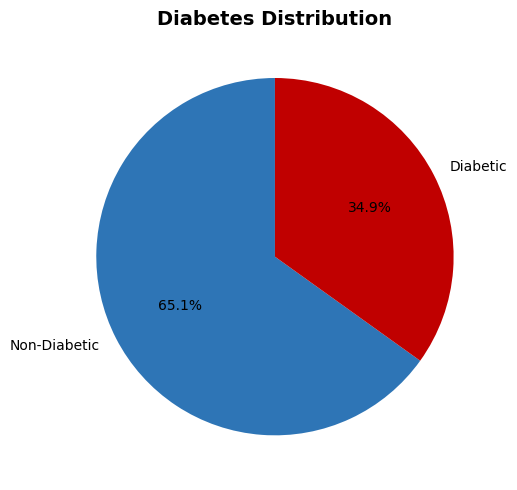

In [9]:
# Chart 1 - Diabetes Distribution
plt.figure(figsize=(6,5))
colors = ['#2E75B6','#C00000']
df['Outcome'].value_counts().plot(kind='pie',
                                   autopct='%1.1f%%',
                                   colors=colors,
                                   labels=['Non-Diabetic','Diabetic'],
                                   startangle=90)
plt.title('Diabetes Distribution', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

### Insight 1 — Diabetes Distribution
- 34.9% of patients are diabetic (268 out of 768)
- 65.1% are non-diabetic (500 out of 768)
- This is 3x higher than global average of 10%
- Pima Indian women have genetic predisposition to diabetes

# Chart 2 - Glucose vs Diabetes

/tmp/ipykernel_3312/3689380155.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Glucose', data=df,


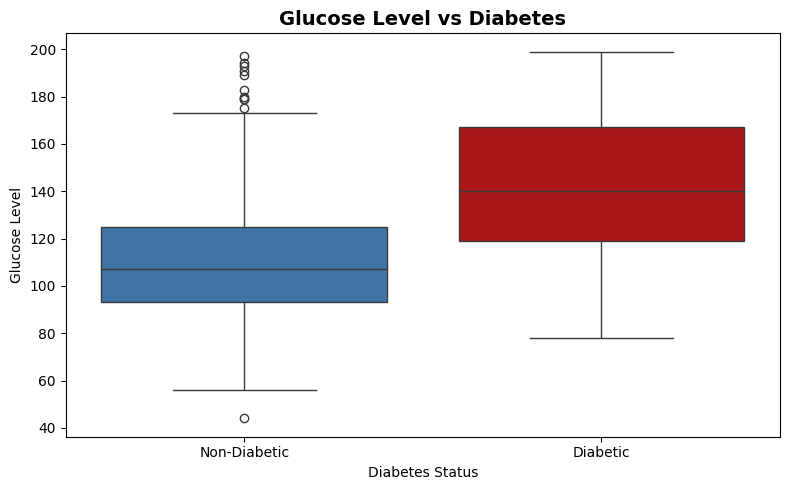

Average Glucose Level:
Outcome
0    110.622000
1    142.302239
Name: Glucose, dtype: float64


In [10]:
# Chart 2 - Glucose vs Diabetes
plt.figure(figsize=(8,5))
sns.boxplot(x='Outcome', y='Glucose', data=df,
            palette=['#2E75B6','#C00000'])
plt.xticks([0,1], ['Non-Diabetic','Diabetic'])
plt.title('Glucose Level vs Diabetes', fontsize=14, fontweight='bold')
plt.xlabel('Diabetes Status')
plt.ylabel('Glucose Level')
plt.tight_layout()
plt.show()

# Print average glucose for each group
print("Average Glucose Level:")
print(df.groupby('Outcome')['Glucose'].mean())


### Insight 2 — Glucose vs Diabetes
- Diabetic patients have significantly higher glucose levels
- Average glucose: Non-Diabetic = 110.6, Diabetic = 142.3
- Diabetic patients have 29% higher glucose on average
- Glucose is clearly a strong predictor of diabetes

### Chart 3 — BMI vs Diabetes
Does higher BMI lead to higher diabetes risk?

/tmp/ipykernel_3312/819140850.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='BMI', data=df,


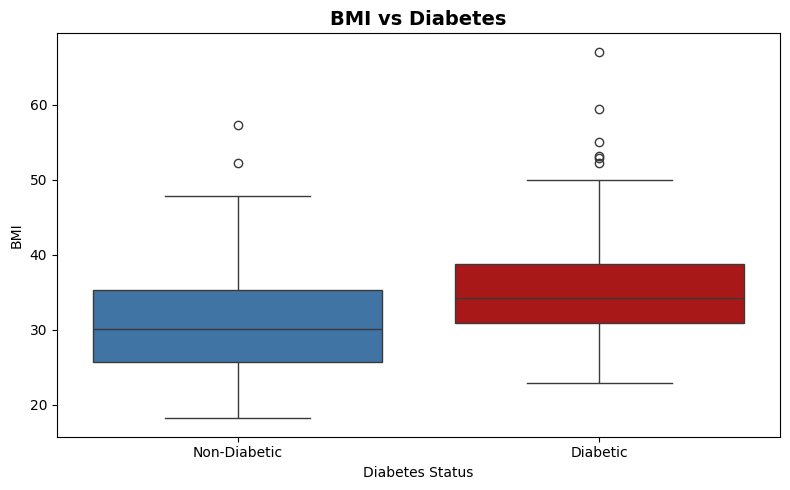

Average BMI:
Outcome
0    30.846000
1    35.398507
Name: BMI, dtype: float64


In [11]:
# Chart 3 - BMI vs Diabetes
plt.figure(figsize=(8,5))
sns.boxplot(x='Outcome', y='BMI', data=df,
            palette=['#2E75B6','#C00000'])
plt.xticks([0,1], ['Non-Diabetic','Diabetic'])
plt.title('BMI vs Diabetes', fontsize=14, fontweight='bold')
plt.xlabel('Diabetes Status')
plt.ylabel('BMI')
plt.tight_layout()
plt.show()

# Average BMI for each group
print("Average BMI:")
print(df.groupby('Outcome')['BMI'].mean())

### Insight 3 — BMI vs Diabetes
- Both groups are in obese category (BMI above 30)
- Non-Diabetic average BMI = 30.84
- Diabetic average BMI = 35.39
- Diabetic patients have 15% higher BMI
- Obesity is a strong risk factor for diabetes

#Chart4. Age vs Diabetes

/tmp/ipykernel_3312/4056167694.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y='Age', data=df,


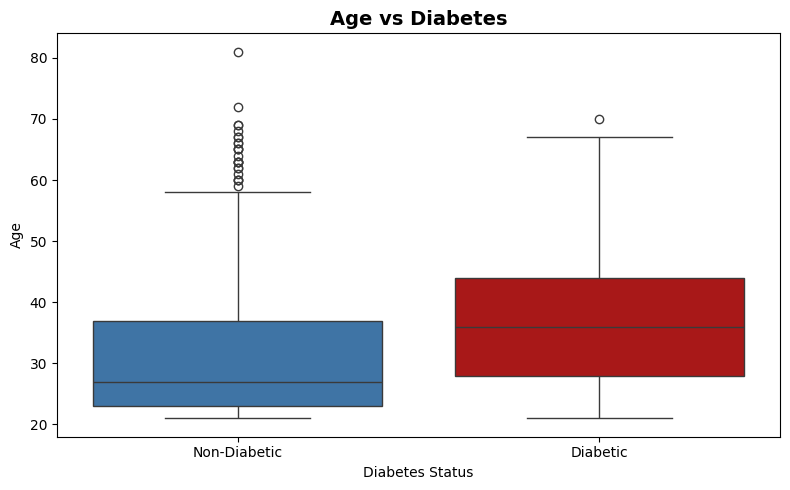

Average Age:
Outcome
0    31.190000
1    37.067164
Name: Age, dtype: float64


In [12]:
# Chart 4 - Age vs Diabetes
plt.figure(figsize=(8,5))
sns.boxplot(x='Outcome', y='Age', data=df,
            palette=['#2E75B6','#C00000'])
plt.xticks([0,1], ['Non-Diabetic','Diabetic'])
plt.title('Age vs Diabetes', fontsize=14, fontweight='bold')
plt.xlabel('Diabetes Status')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

# Average Age for each group
print("Average Age:")
print(df.groupby('Outcome')['Age'].mean())

### Insight 4 — Age vs Diabetes
- Diabetic patients are significantly older on average
- Non-Diabetic average age = 31.19 years
- Diabetic average age = 37.07 years
- Diabetic patients are 19% older on average
- Age is a significant risk factor for diabetes

### Chart 5 — Correlation Heatmap
Which factors are most strongly correlated with diabetes outcome?

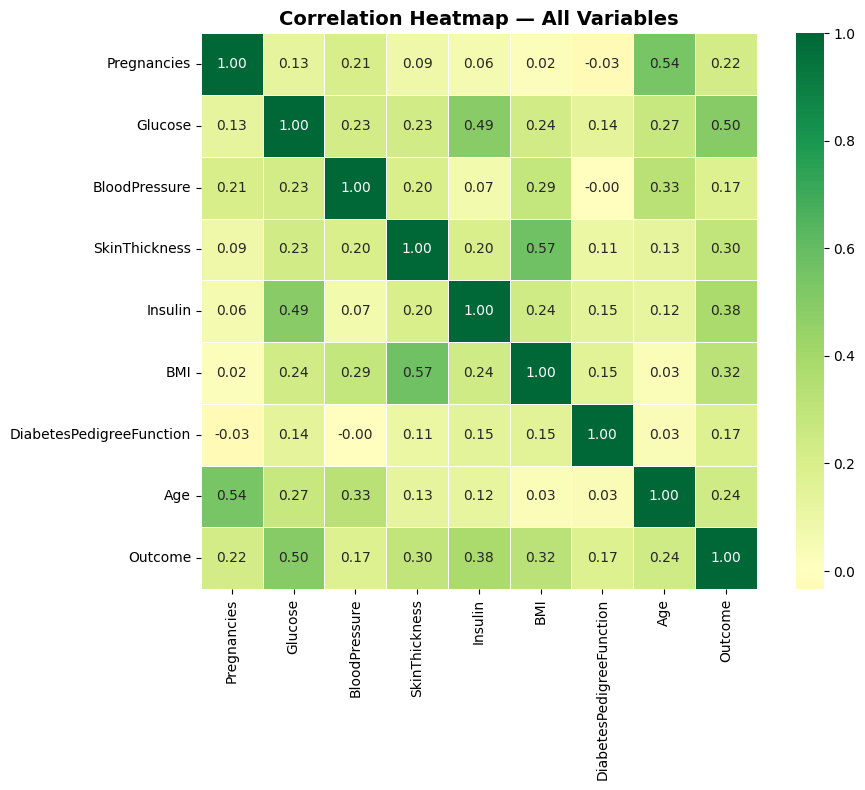

Correlation with Diabetes Outcome:
Outcome                     1.000000
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


In [13]:
# Chart 5 - Correlation Heatmap
plt.figure(figsize=(10,8))
correlation = df.corr()
sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap — All Variables',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print correlation with Outcome specifically
print("Correlation with Diabetes Outcome:")
print(df.corr()['Outcome'].sort_values(ascending=False))

### Insight 5 — Correlation Heatmap
- Glucose has strongest correlation with diabetes (0.50)
- Top 3 diabetes risk factors:
  1. Glucose level (0.50) — strongest predictor
  2. Insulin level (0.38) — second strongest
  3. BMI (0.32) — third strongest
- Blood Pressure has weakest relationship (0.17)
- Early screening should focus on Glucose and Insulin levels

## Final Summary — Healthcare Diabetes Analysis

### Dataset Overview
- Dataset: Pima Indians Diabetes Dataset
- Total Patients: 768 women aged 21 and above
- Tools Used: Python (Pandas, Matplotlib, Seaborn)

### Key Findings

| # | Finding | Value |
|---|---|---|
| 1 | Overall Diabetes Rate | 34.9% — 3x higher than global average |
| 2 | Glucose — Diabetic vs Non-Diabetic | 142.3 vs 110.6 — 29% higher |
| 3 | BMI — Diabetic vs Non-Diabetic | 35.39 vs 30.84 — 15% higher |
| 4 | Age — Diabetic vs Non-Diabetic | 37.07 vs 31.19 — 19% higher |
| 5 | Strongest Diabetes Predictor | Glucose (correlation 0.50) |
| 6 | Top 3 Risk Factors | Glucose, Insulin, BMI |

### Recommendations
- Early diabetes screening should prioritise Glucose and Insulin testing
- Weight management programs can significantly reduce diabetes risk
- Women above 35 years should get regular diabetes checkups
- Pima Indian community needs targeted healthcare intervention

### Conclusion
Glucose level is the strongest predictor of diabetes followed by
Insulin and BMI. Age and number of pregnancies also show moderate
correlation. Early detection focusing on these key risk factors
can significantly improve patient outcomes.